In [305]:
import cenpy as cen
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point

from matplotlib import pyplot as plt
import seaborn as sns

import hvplot.pandas
import holoviews as hv
import carto2gpd

acs = cenpy.remote.APIConnection("ACSDT5Y2019")
variables = [
    "NAME",
    "B03002_001E", # Total
    "B03002_003E", # Not Hispanic, White
    "B03002_004E", # Not Hispanic, Black
    "B03002_005E", # Not Hispanic, American Indian
    "B03002_006E", # Not Hispanic, Asian
    "B03002_007E", # Not Hispanic, Native Hawaiian
    "B03002_008E", # Not Hispanic, Other
    "B03002_009E", # Not Hispanic, Two or More Races
    "B03002_012E", # Hispanic
]


In [306]:
#Angola 22, 125
#Parchman 28, 133
#lafourche 22, 057

state_code = "22"
county_code = "057"

data = acs.query(
    cols=variables,
    geo_unit="block group:*",
    geo_filter={"state": state_code, 
                "county": county_code, 
                "tract": "*"},
)


data.head()

,NAME,B03002_001E,B03002_003E,B03002_004E,B03002_005E,B03002_006E,B03002_007E,B03002_008E,B03002_009E,B03002_012E,state,county,tract,block group
0,"Block Group 2, Census Tract 216.01, Lafourche ...",996,933,0,63,0,0,0,0,0,22,057,021601,2
1,"Block Group 3, Census Tract 214, Lafourche Par...",1733,1452,0,26,1,0,0,148,106,22,057,021400,3
2,"Block Group 2, Census Tract 204, Lafourche Par...",618,104,452,0,0,0,39,10,13,22,057,020400,2
3,"Block Group 3, Census Tract 215, Lafourche Par...",1542,1201,152,0,38,0,0,0,151,22,057,021500,3
4,"Block Group 1, Census Tract 215, Lafourche Par...",1601,1361,0,90,29,0,0,50,71,22,057,021500,1


In [307]:
for variable in variables:
    
    # Convert all variables EXCEPT for NAME
    if variable != "NAME":
       data[variable] = data[variable].astype(float)
        
    

In [308]:
acs.set_mapservice("tigerWMS_ACS2019")

# Use SQL to return geometries only for Philadelphia County in PA
where_clause = f"STATE = {state_code} AND COUNTY = {county_code}"

# Query for block groups
block_groups = acs.mapservice.layers[10].query(where=where_clause)
block_groups.head()

C:\Users\amyli\miniconda3\envs\musa-550-fall-2021\lib\site-packages\pyproj\crs\crs.py:68: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  return _prepare_from_string(" ".join(pjargs))


,MTFCC,OID,GEOID,STATE,COUNTY,TRACT,BLKGRP,BASENAME,NAME,LSADC,FUNCSTAT,AREALAND,AREAWATER,CENTLAT,CENTLON,INTPTLAT,INTPTLON,OBJECTID,geometry
0,G5030,2085958798982,220570204001,22,057,020400,1,1,Block Group 1,BG,S,425727,0,+29.7892573,-090.8152165,+29.7892573,-090.8152165,9724,"POLYGON ((-10109831.549 3476575.141, -10109829..."
1,G5030,2085958799019,220570216012,22,057,021601,2,2,Block Group 2,BG,S,85827870,7793816,+29.6512829,-090.6088927,+29.6568250,-090.6177433,10877,"POLYGON ((-10095292.778 3458046.428, -10095288..."
2,G5030,2085958799041,220570207041,22,057,020704,1,1,Block Group 1,BG,S,40744268,0,+29.8754686,-090.8432174,+29.8754686,-090.8432174,10878,"POLYGON ((-10117355.299 3491389.004, -10117223..."
3,G5030,2085958798981,220570220002,22,057,022000,2,2,Block Group 2,BG,S,452346,0,+29.7954393,-090.8154164,+29.7954393,-090.8154164,10975,"POLYGON ((-10110026.135 3477123.251, -10110024..."
4,G5030,2085958798990,220570202021,22,057,020202,1,1,Block Group 1,BG,S,4651530,0,+29.7675690,-090.7824259,+29.7675690,-090.7824259,11128,"POLYGON ((-10107410.127 3472012.618, -10107405..."


In [309]:
final = block_groups.merge(
    data,
    left_on=["STATE", "COUNTY", "TRACT", "BLKGRP"],
    right_on=["state", "county", "tract", "block group"],
)

In [310]:
# Rename columns
final = final.rename(
    columns={
        "B03002_001E": "Total",  # Total
        "B03002_003E": "White",  # Not Hispanic, White
        "B03002_004E": "Black",  # Not Hispanic, Black
        "B03002_005E": "AI/AN",  # Not Hispanic, American Indian
        "B03002_006E": "Asian",  # Not Hispanic, Asian
        "B03002_007E": "NH/PI",  # Not Hispanic, Native Hawaiian
        #"B03002_008E": "Other_",  # Not Hispanic, Other
        #"B03002_009E": "Two Plus",  # Not Hispanic, Two or More Races
        "B03002_012E": "Hispanic",  # Hispanic
    }
)

# Add an "Other" column 
cols = ['AI/AN', 'NH/PI']
final['Indigenous'] = final[cols].sum(axis=1)

In [311]:
def random_points_in_polygon(number, polygon):
    """
    Generate a random number of points within the 
    specified polygon.
    """
    points = []
    min_x, min_y, max_x, max_y = polygon.bounds
    i= 0
    while i < number:
        point = Point(np.random.uniform(min_x, max_x), np.random.uniform(min_y, max_y))
        if polygon.contains(point):
            points.append(point)
            i += 1
    return points

In [312]:
def generate_dot_map(data, people_per_dot):
    """
    Given a GeoDataFrame with demographic columns, generate a dot 
    map according to the population in each geometry.
    """
    results = []
    for field in ["White", "Hispanic", "Black", "Asian", "Indigenous"]:

        # generate random points
        pts = data.apply(
            lambda row: random_points_in_polygon(
                row[field] / people_per_dot, row["geometry"]
            ),
            axis=1,
        )

        # combine into single GeoSeries
        pts = gpd.GeoSeries(pts.apply(pd.Series).stack(), crs=data["geometry"].crs)
        pts.name = "geometry"

        # make into a GeoDataFrame
        pts = gpd.GeoDataFrame(pts)
        pts["field"] = field

        # save
        results.append(pts)

    return gpd.GeoDataFrame(pd.concat(results), crs=data["geometry"].crs).reset_index(
        drop=True
    )

In [313]:
dot_map = generate_dot_map(final, people_per_dot=1)

# setup a custom color map from ColorBrewer
from matplotlib.colors import ListedColormap

cmap = ListedColormap(
    ["#29668f", "#027d64", "#d286d9", "#f58e20", "#c2ab48"]
)
# Convert to 3857
dot_map_3857 = dot_map.to_crs(epsg=3857)


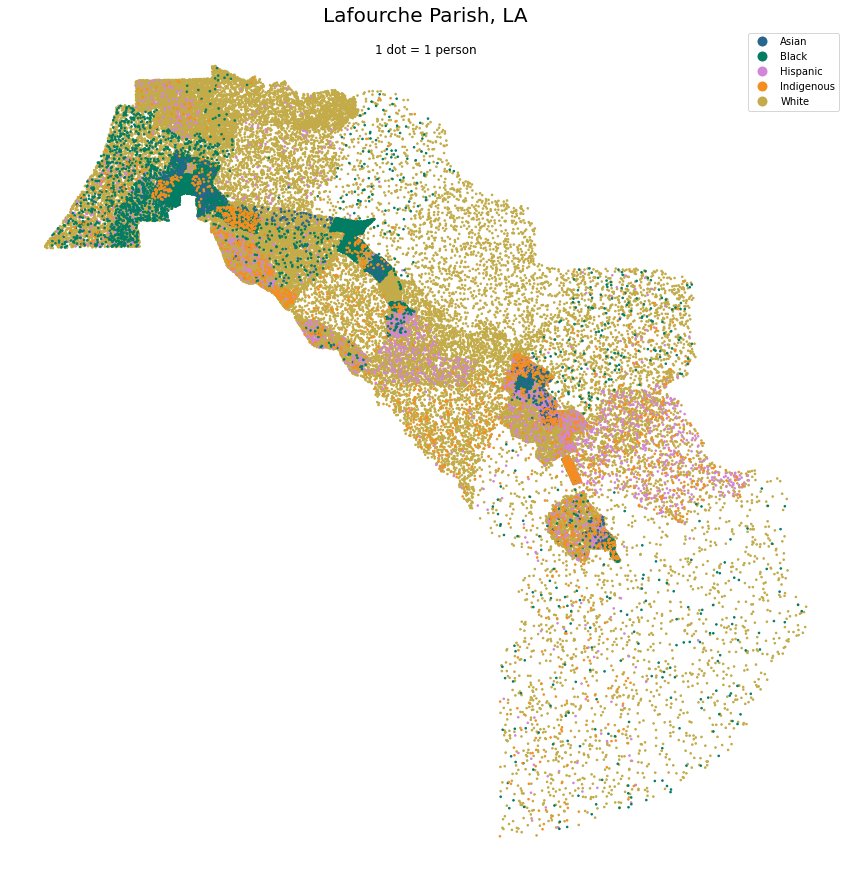

In [314]:
# Initialize the figure and axes
fig, ax = plt.subplots(figsize=(15, 25), facecolor="#ffffff")

# Plot
dot_map_3857.plot(
    ax=ax,
    column="field",
    categorical=True,
    legend=True,
    alpha=1,
    markersize=2.5,
    cmap=cmap,
)


# format
ax.set_title("Lafourche Parish, LA", fontname="Helvetica", fontsize=20)
ax.text(
    0.5, 0.97, "1 dot = 1 person", fontname="Helvetica", fontsize=12, transform=ax.transAxes, ha="center"
)
ax.set_axis_off()

